In [183]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [184]:
df = pd.read_csv("ic272_lab5_rent.csv")

In [185]:
df.shape

(300, 14)

In [186]:
df.isnull().sum()

area           0
rooms          0
age            0
dist_km        0
floors         0
noise_a        0
noise_b        0
noise_c        0
noise_d        0
noise_id       0
noise_tiny1    0
noise_tiny2    0
noise_tiny3    0
rent           0
dtype: int64

In [187]:
print(f"{'Features':14s}{'Min val':>13s}{'Max val':>13}")

for feat , mn , mx in zip(df.columns , df.min() , df.max()):
    print(f"{feat:14s}{mn:>13.6f}{mx:>13.6f}")

Features            Min val      Max val
area               5.050000     9.500000
rooms              1.000000     5.000000
age                0.000000     7.950000
dist_km            1.020000     8.910000
floors             1.000000     3.000000
noise_a           -5.566000     6.722000
noise_b           -6.498000     6.346000
noise_c           -5.606000     6.197000
noise_d           -5.927000     5.875000
noise_id      100026.300000104986.600000
noise_tiny1       -0.145810     0.150300
noise_tiny2       -0.122340     0.123490
noise_tiny3       -0.138490     0.116580
rent              29.550000    85.940000


In [188]:
features = [ i for i in df.columns if i != "rent"]

In [189]:
x = df[features].to_numpy(float)
y = df["rent"].to_numpy(float)

In [190]:
x.shape

(300, 13)

In [191]:
y.shape

(300,)

In [192]:
def train_test_split(x,y,test_size,seed):

    n = len(y)

    rng = np.random.default_rng(seed)

    idx = rng.permutation(n)

    n_test = int(n*test_size)

    train_idx = idx[n_test :]
    test_idx = idx[:n_test]

    return (x[train_idx] , x[test_idx] , y[train_idx] , y[test_idx])

In [193]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    seed=0
)

In [194]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (240, 13)
X_test shape: (60, 13)
y_train shape: (240,)
y_test shape: (60,)


In [195]:
def fit_simple_lr(x,y):

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numr = np.sum(
        (x-x_mean)*(y-y_mean)
    )

    denr = np.sum(
        (x-x_mean)**2
    )

    w = numr/denr
    b = y_mean - w*x_mean

    return w,b

In [196]:
x_train_area = x_train[:,0]

In [197]:
w , b = fit_simple_lr(
    x_train_area , y_train
)

print(f"w = {w:4f}")
print(f"b : {b:4f}")

w = 5.920584
b : 11.572232


In [198]:
x_test_area = x_test[:,0]
y_pred = w*x_test_area + b

In [199]:
sort_idx = np.argsort(x_test_area)

x_sorted = x_test_area[sort_idx]
y_line = y_pred[sort_idx]

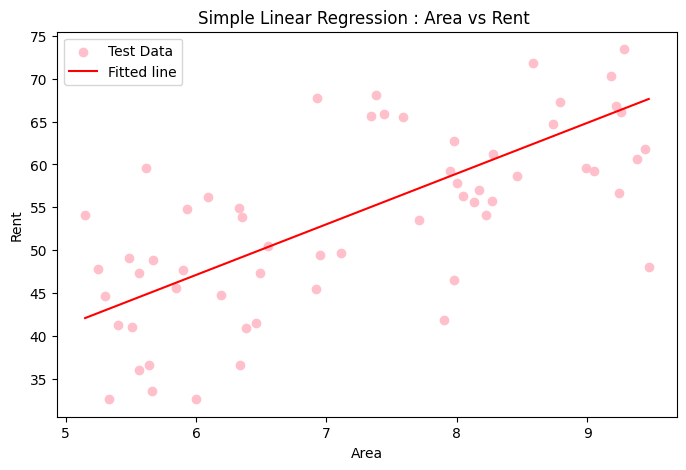

In [200]:
plt.figure(figsize=(8,5))

plt.scatter(
    x_test_area,
    y_test,
    label = "Test Data",
    color = "pink"
)

plt.plot(
    x_sorted,
    y_line,
    label = "Fitted line",
    color = "r"
)

plt.xlabel("Area")
plt.ylabel("Rent")
plt.title("Simple Linear Regression : Area vs Rent ")
plt.legend()

plt.show()

In [201]:
def design_matrix(x):
    return np.c_[np.ones(len(x)),x]

In [202]:
def fit_normal_eqn(x,y):

    A = design_matrix(x)

    theta = np.linalg.solve(A.T@A , A.T@y)

    return theta 

In [203]:
theta_ne = fit_normal_eqn(
    x_train , y_train
)
print(f"Normal Equation Parameter : {theta_ne}")

Normal Equation Parameter : [ 7.79645272e+00  6.04184673e+00  3.23055935e+00 -1.37156719e+00
 -1.80893278e+00  1.83989407e+00  1.20215892e-01  3.61214570e-03
  1.67004812e-01 -1.49378341e-01  3.64024735e-05 -4.64999398e+00
 -8.68425905e+00 -2.25881036e+00]


In [204]:
params = [
    "intercept",
    "area",
    "rooms",
    "age",
    "dist",
    "floors"
]

print(f"Parameters   Values")

for pm , val in zip(params,theta_ne):
    print(f"{pm:<13}{val:4f}")

Parameters   Values
intercept    7.796453
area         6.041847
rooms        3.230559
age          -1.371567
dist         -1.808933
floors       1.839894


In [ ]:
def fit_gradient_descent(x,y,lr,n_iters):

    A = design_matrix(x)

    n = len(y)
    theta = np.zeros(A.shape[1])
    losses = []
    

    for i in range(n_iters):

        y_pred = A@theta
        error = y_pred - y
        loss = np.mean(error**2)
        losses.append(loss)

        gradient = (2/n)*(A.T@error)
        theta = theta -lr*gradient

    return theta , losses

In [206]:
theta_gd, losses = fit_gradient_descent(
    x_train , 
    y_train , 
    lr = 0.005 , 
    n_iters = 20000
)

C:\Users\ohhaa\AppData\Local\Temp\ipykernel_17272\3702538271.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean(error**2)
C:\Users\ohhaa\AppData\Local\Temp\ipykernel_17272\3702538271.py:17: RuntimeWarning: overflow encountered in matmul
  gradient = (2/n)*(A.T@error)
C:\Users\ohhaa\AppData\Local\Temp\ipykernel_17272\3702538271.py:12: RuntimeWarning: invalid value encountered in matmul
  y_pred = A@theta
C:\Users\ohhaa\AppData\Local\Temp\ipykernel_17272\3702538271.py:17: RuntimeWarning: invalid value encountered in matmul
  gradient = (2/n)*(A.T@error)


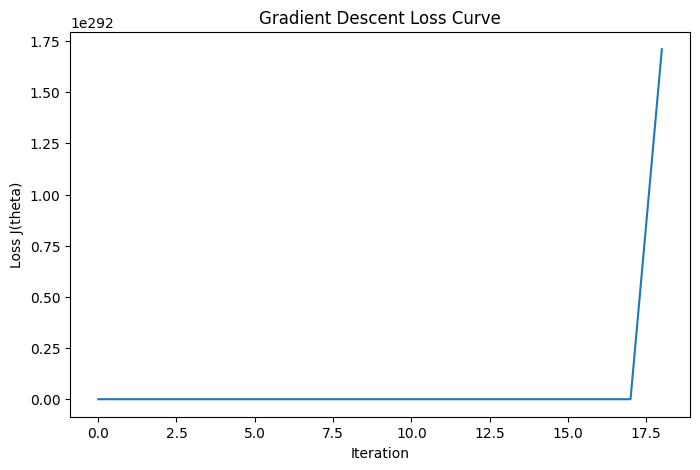

In [207]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Iteration")
plt.ylabel("Loss J(theta)")
plt.title("Gradient Descent Loss Curve")

plt.show()

In [208]:
def standardise(x_train , y_train):

    mu = np.mean(x_train,axis = 0)

    sigma = np.std(x_train , axis = 0)

    x_train_std = (x_train-mu)/sigma
    x_test_std = (x_test - mu)/sigma

    return x_train_std , x_test_std

In [209]:
x_train_std , x_test_std = standardise(
    x_train , x_test
)

In [210]:
print("Training mean:")
print(np.mean(x_train_std, axis=0))

print("\nTraining standard deviation:")
print(np.std(x_train_std, axis=0))

print("\nTest mean:")
print(np.mean(x_test_std, axis=0))

print("\nTest standard deviation:")
print(np.std(x_test_std, axis=0))

Training mean:
[-1.06812707e-15 -3.97829917e-17 -2.21119419e-16 -1.76710498e-16
 -1.81336427e-16  1.29526020e-17  1.89663100e-17 -5.99057840e-17
  6.38378239e-17  6.24500451e-15 -4.16333634e-18  8.32667268e-18
 -1.66533454e-17]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test mean:
[-0.04305093  0.00296332  0.17215519 -0.03961397 -0.15971957 -0.10126537
 -0.18925536  0.15331142  0.03363168  0.09803276  0.21073731  0.04959812
 -0.32762728]

Test standard deviation:
[1.0942556  1.05826534 0.98854991 0.99676022 1.03681791 0.91462359
 1.10958155 1.0650743  0.97531424 1.04681972 1.09042336 1.10288428
 1.07577271]


In [211]:
theta_gd, losses = fit_gradient_descent(
    x_train_std,
    y_train,
    lr=0.001,
    n_iters=20000
)

In [212]:
print("Initial loss:", losses[0])
print("Final loss:", losses[-1])

Initial loss: 3100.9456649999997
Final loss: 5.916663278016419


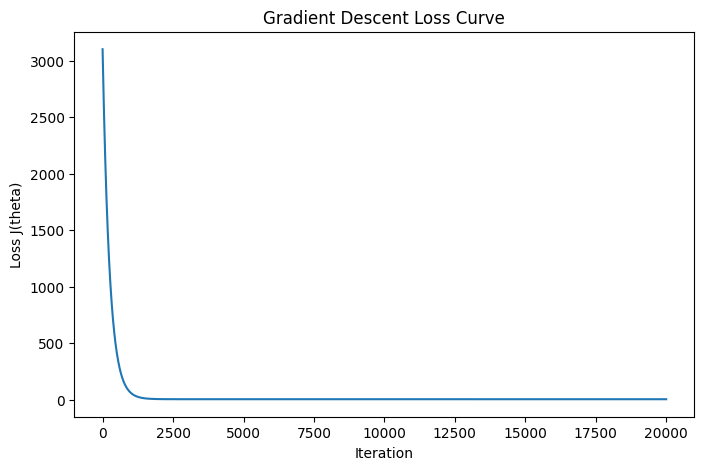

In [213]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Iteration")
plt.ylabel("Loss J(theta)")

plt.title("Gradient Descent Loss Curve")

plt.show()

In [214]:
print("First loss:", losses[0])
print("Loss after 10 iterations:", losses[10])
print("Loss after 100 iterations:", losses[100])
print("Loss after 1000 iterations:", losses[1000])
print("Final loss:", losses[-1])

First loss: 3100.9456649999997
Loss after 10 iterations: 2979.285534337311
Loss after 100 iterations: 2078.6652925228727
Loss after 1000 iterations: 62.63995972303594
Final loss: 5.916663278016419


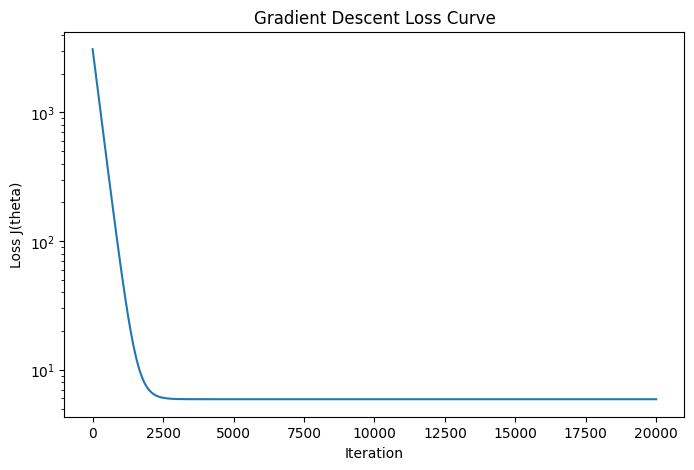

In [215]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Loss J(theta)")

plt.title("Gradient Descent Loss Curve")

plt.show()

In [216]:
def fit_ridge(x,y,lam):

    A = design_matrix(x)
    p = A.shape[1]

    I = np.eye(p)
    I[0,0] = 0

    ridge_matriz = A.T@A + lam*I

    rhs = A.T@y

    theta = np.linalg.solve(ridge_matriz,rhs)

    #theta = np.linalg.solve( A.T@A + lam*I , A.T@y )

    return theta 

In [217]:
lams = [0,1,10,100]

for lam in lams:

    theta = fit_ridge(
        x_train_std,
        y_train,
        lam
    )

    print(f"lamda : {lam}\n")
    print(f"coeffs : \n") 

    print(theta)

    zero_cnt = np.sum(np.abs(theta[1:]) < 1e-8 )

    print("\nNumber of zeroes coefficients :" , zero_cnt) 

lamda : 0

coeffs : 

[ 5.46555833e+01  7.56091673e+00  4.54243064e+00 -3.01087691e+00
 -4.19157520e+00  1.48793909e+00  2.46909714e-01  6.94002200e-03
  3.42740126e-01 -3.03101968e-01  5.30786393e-02 -2.31102438e-01
 -4.05390243e-01 -1.05135788e-01]

Number of zeroes coefficients : 0
lamda : 1

coeffs : 

[ 5.46555833e+01  7.52765036e+00  4.52267216e+00 -2.99701251e+00
 -4.17499225e+00  1.48418162e+00  2.41018714e-01  1.12155096e-02
  3.38742095e-01 -3.00697412e-01  5.12078749e-02 -2.34698000e-01
 -4.05721629e-01 -1.02704029e-01]

Number of zeroes coefficients : 0
lamda : 10

coeffs : 

[ 5.46555833e+01  7.24135339e+00  4.35274111e+00 -2.87824567e+00
 -4.03156716e+00  1.45061166e+00  1.92110408e-01  4.63723988e-02
  3.05056610e-01 -2.80735487e-01  3.54705462e-02 -2.63776027e-01
 -4.07783192e-01 -8.28248936e-02]

Number of zeroes coefficients : 0
lamda : 100

coeffs : 

[ 5.46555833e+01  5.26162748e+00  3.17939166e+00 -2.07816234e+00
 -3.00502665e+00  1.16170727e+00 -5.93619623e-02  2.

In [218]:
theta_ridge_0 = fit_ridge(
    x_train_std,
    y_train,
    0
)

theta_ordinary = fit_normal_eqn(
    x_train_std,
    y_train
)

print(
    np.allclose(
        theta_ridge_0,
        theta_ordinary
    )
)

True


In [219]:
def rmse(y_true,y_pred):

    return np.sqrt(
        np.mean(
            (y_true - y_pred)**2
        )
    )

In [220]:
def k_fold_cv(x,y,lam,k=5,seed=0):

    n = len(y)

    idx = np.random.default_rng(seed).permutation(n)

    folds = np.array_split(idx,k)
    fold_rmse = []

    for i,val_idx in enumerate(folds):

        train_idx = np.concatenate(folds[:i]+folds[i+1:])

        theta = fit_ridge(x[train_idx],y[train_idx],lam)

        y_pred = design_matrix(x[val_idx])@theta
        fold_rmse.append(rmse(y[val_idx],y_pred))

    return np.mean(fold_rmse)

In [221]:
cv_test = k_fold_cv(
    x_train_std,
    y_train,
    lam = 1,
    k = 5 ,
    seed = 0
)

print(f"CV rmse : {cv_test:4f}")

CV rmse : 2.599667


In [222]:
lambs = [
    0,0.1,0.3,1,3,10,30,100
]

cv_res = []

for lam in lambs:

    cv_rmse = k_fold_cv(
        x_train_std,
        y_train,
        lam,
        k=5,
        seed=0
    )

    cv_res.append(cv_rmse)

    print(
        f"lambda = {lam:6.1f}\n"
        f"CV RMSE = {cv_rmse:.4f}\n"
    )

lambda =    0.0
CV RMSE = 2.5994

lambda =    0.1
CV RMSE = 2.5994

lambda =    0.3
CV RMSE = 2.5993

lambda =    1.0
CV RMSE = 2.5997

lambda =    3.0
CV RMSE = 2.6043

lambda =   10.0
CV RMSE = 2.6571

lambda =   30.0
CV RMSE = 3.0040

lambda =  100.0
CV RMSE = 4.5348



In [223]:
best_idx = np.argmin(cv_res)

best_lamda = lambs[best_idx]

best_cv_rmse = cv_res[best_idx]

print(f"\nBest Lamda : {best_lamda}")
print(f"Best CV RMSE : {best_cv_rmse}")


Best Lamda : 0.3
Best CV RMSE : 2.5993254392211322


In [224]:
theta_best = fit_ridge(
    x_train_std,
    y_train,
    best_lamda
)

In [225]:
A_test = design_matrix(x_test_std)
y_test_pred = A_test@theta_best

test_rmse_best = rmse(
    y_test,
    y_test_pred
)

print(
    f"Test RMSE at chosen lamda : ",
    test_rmse_best
)

Test RMSE at chosen lamda :  2.9287017290851987


In [226]:
theta_lamda_0 = fit_ridge(
    x_train_std,
    y_train,0
)
A_Test = design_matrix(x_test_std)

y_test_pred_0 = A_Test@theta_lamda_0

test_rmse_0 = rmse(
    y_test,y_test_pred_0
)

print(f"Test RMSE at lamda = 0 : {test_rmse_0}")
print(f"Test RMSE at choosen lamda : {test_rmse_best}")

Test RMSE at lamda = 0 : 2.9273809842577383
Test RMSE at choosen lamda : 2.9287017290851987


In [227]:
idx = np.random.default_rng(0).permutation(len(y))

In [228]:
tr , te = idx[:40] , idx[40:]
x_train , x_test = x[tr] , x[te]
y_train , y_test = y[tr] , y[te]

In [229]:
x.shape

(300, 13)

In [230]:
x_train.shape

(40, 13)

In [231]:
x_test.shape

(260, 13)

In [232]:
def design_matrix(x):

    return np.c_[np.ones(len(x)),x]

In [233]:
def fit_normal_equation(x,y):
    A = design_matrix(x)
    return np.linalg.solve(A.T@A , A.T@y)

In [234]:
theta_raw = fit_normal_equation(x_train,y_train)
print(theta_raw)

[ 5.47393375e+01  6.20349147e+00  3.56509271e+00 -1.48893182e+00
 -2.14784155e+00  1.91492170e+00 -4.44266989e-01 -1.81942372e-01
 -3.99040220e-01  1.08699911e-01 -4.27191797e-04 -1.12210040e+01
 -6.36955055e+00 -1.19927883e+01]


In [235]:
print(f"{'feature':14s}{'coefficient':>13}{'column sd':>12}")

for feat, coef, sd in zip(features, theta_raw[1:], x.std(axis=0)):
    print(f"{feat:14s}{coef:>13.6f}{sd:>12.6f}")

feature         coefficient   column sd
area               6.203491    1.276070
rooms              3.565093    1.422845
age               -1.488932    2.195416
dist_km           -2.147842    2.315945
floors             1.914922    0.816388
noise_a           -0.444267    2.021746
noise_b           -0.181942    1.970590
noise_c           -0.399040    2.083478
noise_d            0.108700    2.019355
noise_id          -0.000427 1473.122250
noise_tiny1      -11.221004    0.050803
noise_tiny2       -6.369551    0.047689
noise_tiny3      -11.992788    0.047663
